# EDA - Iris

## Objetivo
Realizar un análisis exploratorio inicial del dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


## 1. Carga del dataset


In [2]:
df = pd.read_csv('/content/iris.csv')
print('Shape:', df.shape)
print('Columnas:', df.columns.tolist())
display(df.head())
display(df.tail())
df.info()


Shape: (150, 6)
Columnas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'target_name']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## 2. Estadísticas descriptivas


In [3]:
display(df.describe().T)

numericas = df.select_dtypes(include=['int64','float64']).columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print('Variables numéricas:', numericas)
print('Variables categóricas:', categoricas)


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


Variables numéricas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']
Variables categóricas: ['target_name']


## 3. Distribución de variables categóricas


In [4]:
for col in categoricas:
    print('\n', col)
    display(df[col].value_counts(dropna=False))



 target_name


,count
target_name,
setosa,50
versicolor,50
virginica,50


## 4. Valores nulos y duplicados


In [5]:
print('Valores nulos por columna:')
display(df.isnull().sum())

duplicados = df.duplicated().sum()
print('Filas duplicadas:', duplicados)
print('Porcentaje:', round(duplicados / len(df) * 100, 2), '%')


Valores nulos por columna:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
target_name,0


Filas duplicadas: 1
Porcentaje: 0.67 %


## 5. Histogramas


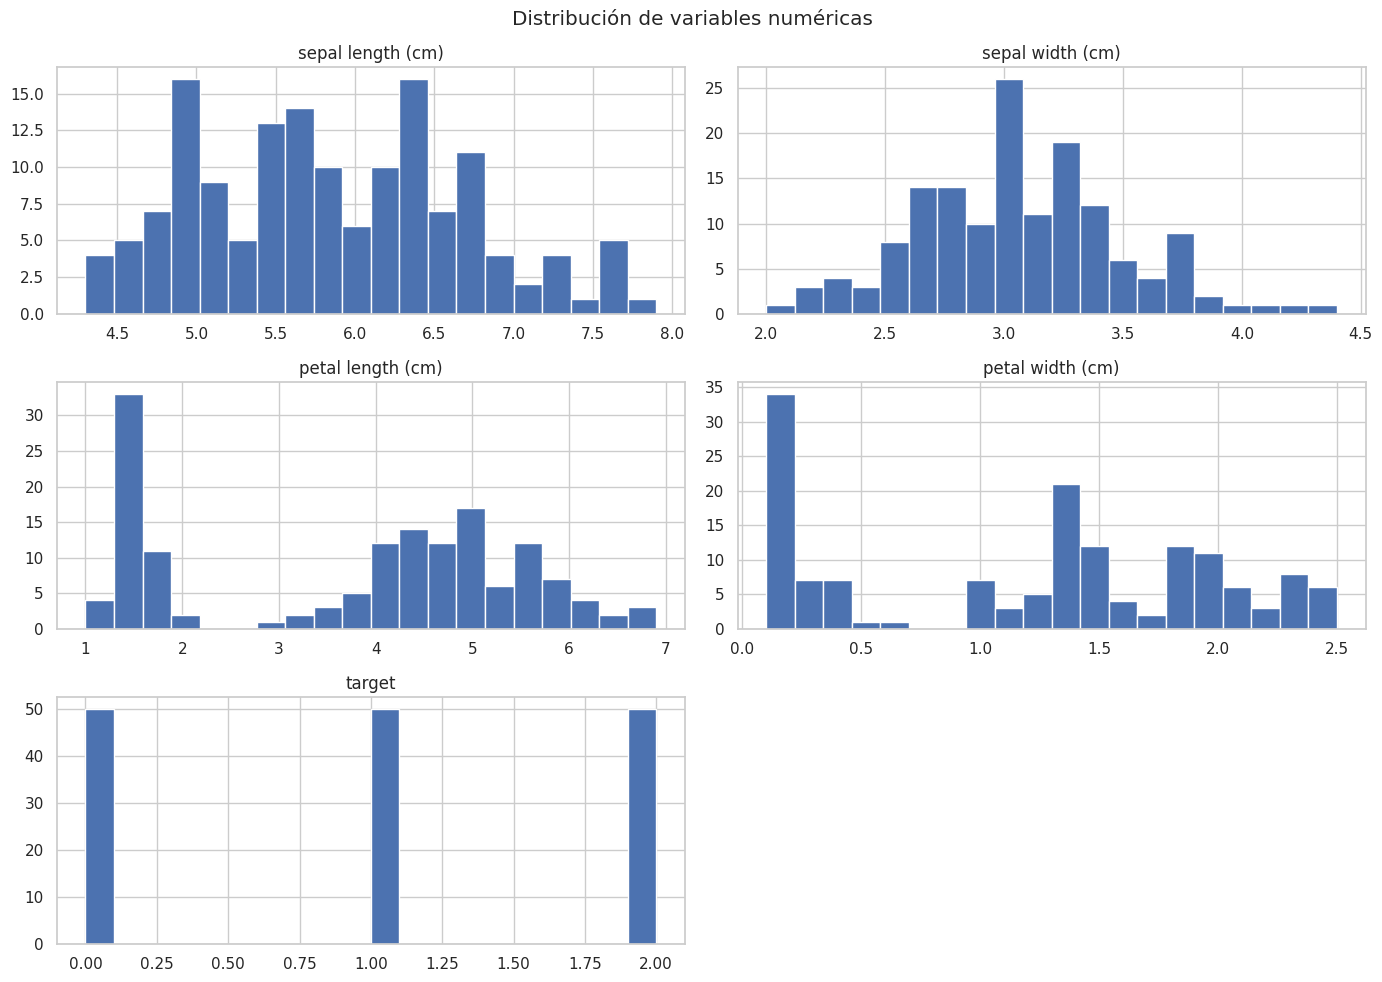

In [6]:
df[numericas].hist(figsize=(14,10), bins=20)
plt.suptitle('Distribución de variables numéricas')
plt.tight_layout()
plt.show()


## 6. Gráficos de barras


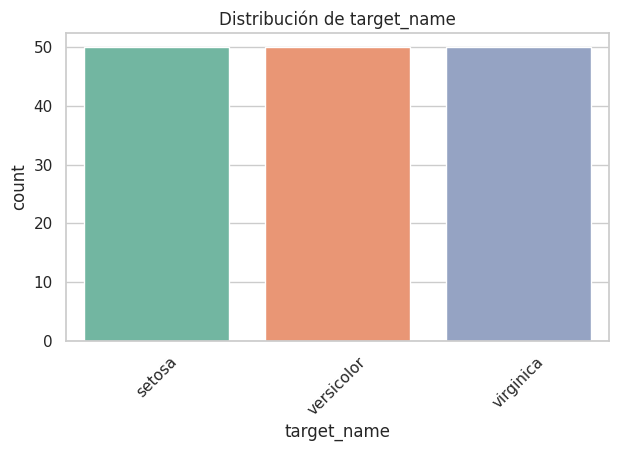

In [7]:
if len(categoricas) > 0:
    for col in categoricas:
        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
        plt.title('Distribución de ' + col)
        plt.xticks(rotation=45)
        plt.show()
else:
    print('No hay variables categóricas de tipo object.')


## 7. Boxplots e identificación de outliers


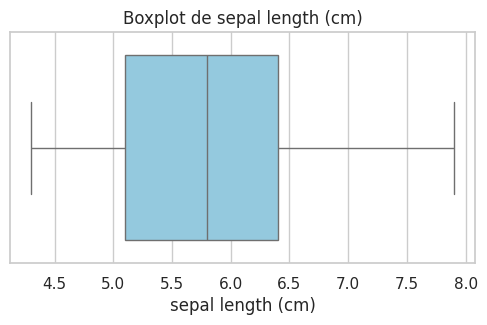

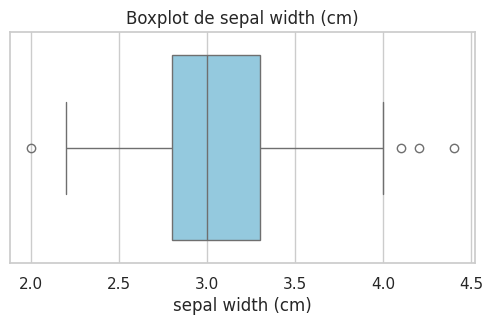

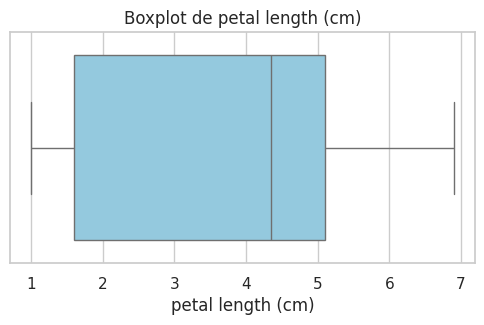

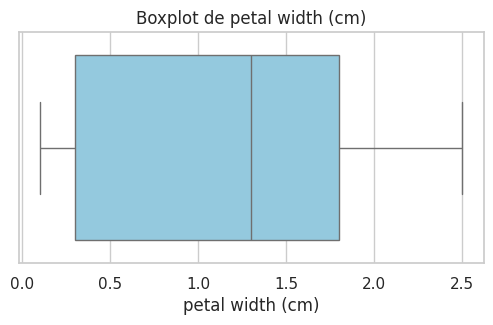

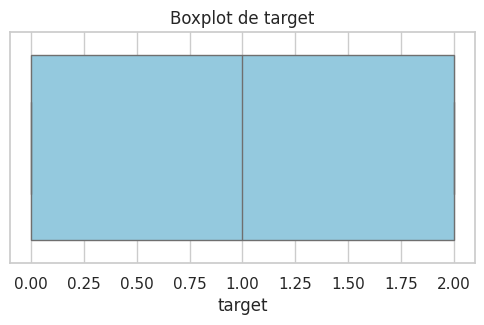

sepal length (cm) : 0 outliers
sepal width (cm) : 4 outliers
petal length (cm) : 0 outliers
petal width (cm) : 0 outliers
target : 0 outliers


In [8]:
for col in numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title('Boxplot de ' + col)
    plt.show()

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    inferior = Q1 - 1.5 * IQR
    superior = Q3 + 1.5 * IQR
    cantidad = ((df[col] < inferior) | (df[col] > superior)).sum()
    print(col, ':', cantidad, 'outliers')


## 8. Mapa de calor de correlación


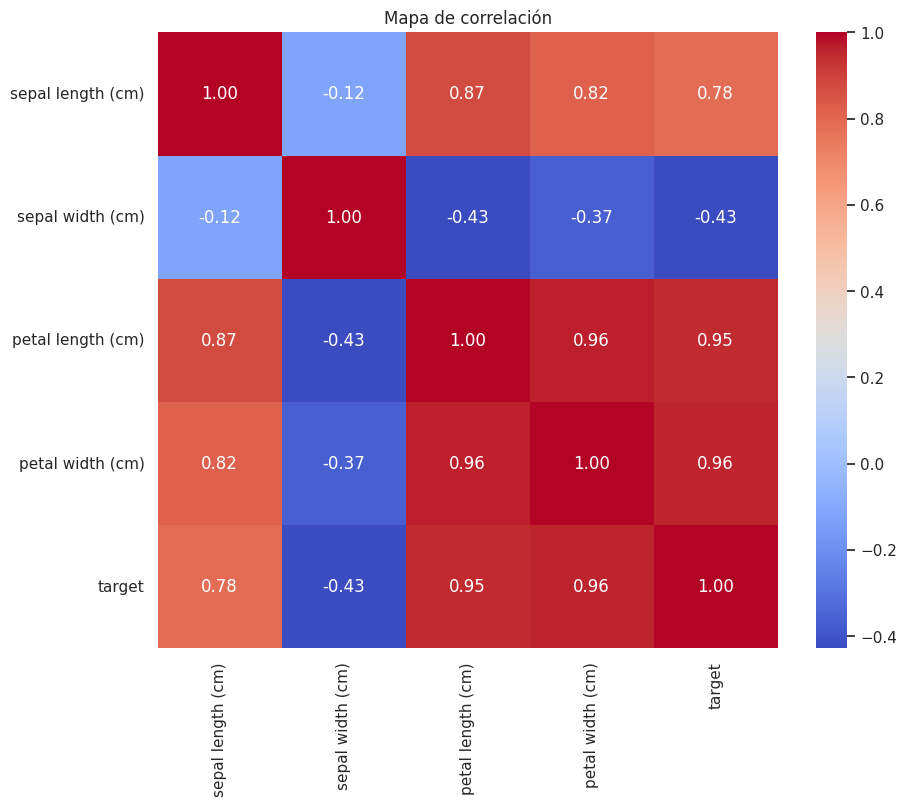

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de correlación')
plt.show()


## 9. Diagnóstico inicial

**Tipo de problema sugerido:** Clasificación multiclase.

**Variable objetivo sugerida:** `target`.

**Resumen:** Dataset adecuado para practicar EDA, preprocesamiento y modelado inicial.
